In [1]:
import pandas as pd

data = pd.read_csv("td3.csv", sep = ",")
data

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,1,3,1,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,1,3,2,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,1,2,2,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,1,3,1,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


In [2]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   30000 non-null

In [3]:
for col in data.columns:
    col = data[col]
    count = col.nunique()
    nbre_manquant = col.isnull().sum()
    print(f"le nom de la colonne est : {col.name}, elle possède {count} valeurs uniques et possede {nbre_manquant} valeurs manquantes")
    

le nom de la colonne est : ID, elle possède 30000 valeurs uniques et possede 0 valeurs manquantes
le nom de la colonne est : LIMIT_BAL, elle possède 81 valeurs uniques et possede 0 valeurs manquantes
le nom de la colonne est : SEX, elle possède 2 valeurs uniques et possede 0 valeurs manquantes
le nom de la colonne est : EDUCATION, elle possède 7 valeurs uniques et possede 0 valeurs manquantes
le nom de la colonne est : MARRIAGE, elle possède 4 valeurs uniques et possede 0 valeurs manquantes
le nom de la colonne est : AGE, elle possède 56 valeurs uniques et possede 0 valeurs manquantes
le nom de la colonne est : PAY_0, elle possède 11 valeurs uniques et possede 0 valeurs manquantes
le nom de la colonne est : PAY_2, elle possède 11 valeurs uniques et possede 0 valeurs manquantes
le nom de la colonne est : PAY_3, elle possède 11 valeurs uniques et possede 0 valeurs manquantes
le nom de la colonne est : PAY_4, elle possède 11 valeurs uniques et possede 0 valeurs manquantes
le nom de la col

3. Analyser la variable cible et étudier son lien avec le sexe, l’âge et le niveau d’éducation à
l’aide de statistiques et de visualisations.

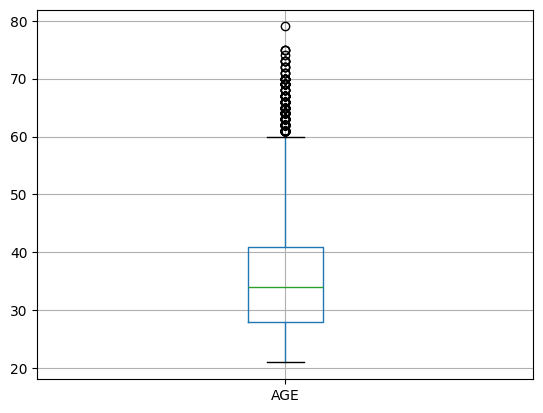

In [4]:
import matplotlib.pyplot as plt

# Compare Credit Limit (LIMIT_BAL) by Sex
data.boxplot(column='AGE')
plt.show()

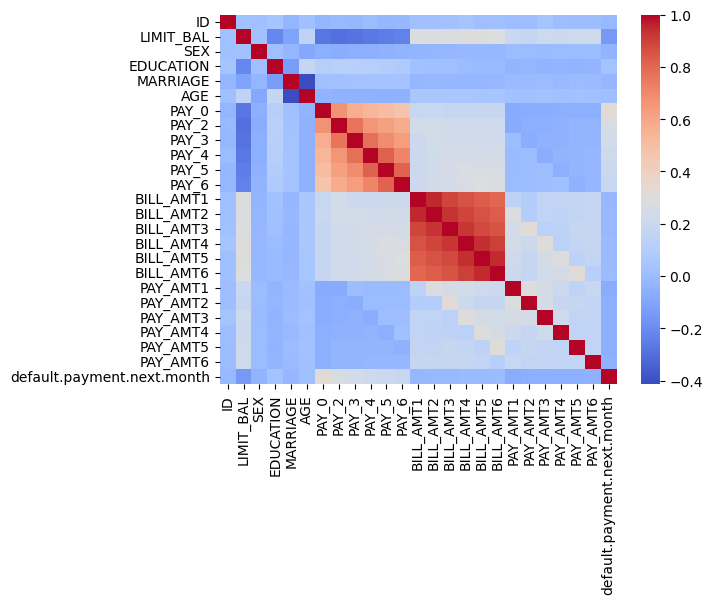

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(data.corr(), cmap="coolwarm")
plt.show()

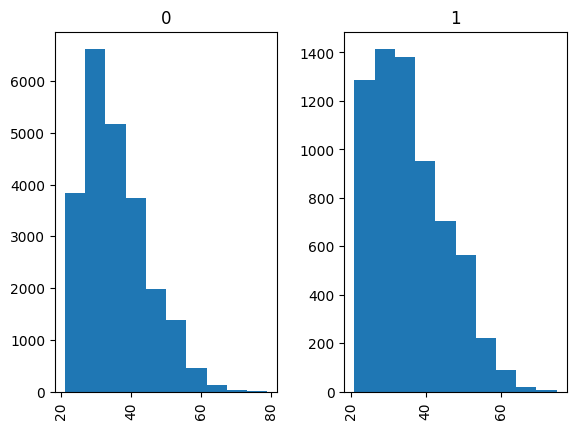

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
data.hist(column='AGE', by='default.payment.next.month')
plt.show()


4. Créer des variables pertinentes liées au comportement de paiement et analyser leur impact
sur le défaut.

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# --- ÉTAPE 4 : Création de variables (Feature Engineering) ---

pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

data['PAY_AVG'] = data[pay_cols].mean(axis=1)

# 2. Taux d'utilisation moyen du crédit
data['UTIL_AVG'] = data[bill_cols].mean(axis=1) / data['LIMIT_BAL']

# 3. Ratio de remboursement (Total payé / Total facturé)
total_bill = data[bill_cols].sum(axis=1)
total_pay = data[pay_amt_cols].sum(axis=1)
data['REPAY_RATIO'] = total_pay / (total_bill + 1)
data

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,PAY_AVG,UTIL_AVG,REPAY_RATIO
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,689.0,0.0,0.0,0.0,0.0,1,-0.333333,0.064200,0.089422
1,2,120000.0,2,2,2,26,-1,2,0,0,...,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1,0.500000,0.023718,0.292774
2,3,90000.0,2,2,2,34,0,0,0,0,...,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0,0.000000,0.188246,0.108387
3,4,50000.0,2,2,1,37,0,0,0,0,...,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0,0.000000,0.771113,0.036259
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0,-0.333333,0.364463,0.540049
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,1,3,1,39,0,0,0,0,...,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0,0.000000,0.549507,0.058661
29996,29997,150000.0,1,3,2,43,-1,-1,-1,-1,...,1837.0,3526.0,8998.0,129.0,0.0,0.0,0,-0.666667,0.023536,0.684039
29997,29998,30000.0,1,2,2,37,4,3,2,-1,...,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1,1.333333,0.391644,0.443991
29998,29999,80000.0,1,3,1,41,1,-1,0,0,...,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1,-0.166667,0.555440,0.552042


5. Construire le dataset final, encoder les variables catégorielles, définir X et y, puis normaliser
les données.


In [8]:
from sklearn.preprocessing import StandardScaler

data_model = pd.get_dummies(data, columns=['EDUCATION', 'MARRIAGE'], drop_first=True)

X = data_model.drop(['ID', 'default.payment.next.month'], axis=1)
y = data_model['default.payment.next.month']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_final = pd.DataFrame(X_scaled, columns=X.columns)

print("Dataset final construit, encodé et normalisé.")
X_final.head()


Dataset final construit, encodé et normalisé.


,LIMIT_BAL,SEX,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,...,REPAY_RATIO,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,EDUCATION_5,EDUCATION_6,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3
0,-1.136720,0.810161,-1.246020,1.794564,1.782348,-0.696663,-0.666599,-1.530046,-1.486041,-0.642501,...,-0.016683,-0.738375,1.0669,-0.442752,-0.064163,-0.097063,-0.041266,1.093780,-1.066471,-0.104326
1,-0.365981,0.810161,-1.029047,-0.874991,1.782348,0.138865,0.188746,0.234917,1.992316,-0.659219,...,-0.016522,-0.738375,1.0669,-0.442752,-0.064163,-0.097063,-0.041266,-0.914261,0.937672,-0.104326
2,-0.597202,0.810161,-0.161156,0.014861,0.111736,0.138865,0.188746,0.234917,0.253137,-0.298560,...,-0.016668,-0.738375,1.0669,-0.442752,-0.064163,-0.097063,-0.041266,-0.914261,0.937672,-0.104326
3,-0.905498,0.810161,0.164303,0.014861,0.111736,0.138865,0.188746,0.234917,0.253137,-0.057491,...,-0.016726,-0.738375,1.0669,-0.442752,-0.064163,-0.097063,-0.041266,1.093780,-1.066471,-0.104326
4,-0.905498,-1.234323,2.334029,-0.874991,0.111736,-0.696663,0.188746,0.234917,0.253137,-0.578618,...,-0.016325,-0.738375,1.0669,-0.442752,-0.064163,-0.097063,-0.041266,1.093780,-1.066471,-0.104326


Exercice 2 : Modèle KNN
1. Diviser les données en ensembles d’entraînement et de test, déterminer la meilleure valeur
de K, entraîner le modèle KNN et effectuer les prédictions.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

scores = []
k_range = range(1, 21)
for k in k_range:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train, y_train)
    scores.append(knn_model.score(X_test, y_test))

# Sélection du meilleur K
best_k = k_range[scores.index(max(scores))]
print(f"Meilleur K trouvé : {best_k}")

Meilleur K trouvé : 19


In [10]:
# 3. Entraînement du modèle final et calcul des prédictions
best_k = 19

final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

2. Évaluer les performances du modèle à l’aide de la matrice de confusion, de la précision, du
recall, du F1-score et du score de Jaccard.

In [11]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, jaccard_score

# Calcul des indicateurs demandés
conf = confusion_matrix(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
jac = jaccard_score(y_test, y_pred)

# Affichage des résultats
print("--- Résultats de l'Évaluation ---")
print(f"Matrice de confusion :\n{conf}\n")
print(f"Précision : {prec:.4f}")
print(f"Recall (Rappel) : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"Score de Jaccard : {jac:.4f}")


--- Résultats de l'Évaluation ---
Matrice de confusion :
[[4479  208]
 [ 927  386]]

Précision : 0.6498
Recall (Rappel) : 0.2940
F1-Score : 0.4048
Score de Jaccard : 0.2538


Exercice 3 : Modèle SVM
1. Tester différents noyaux SVM, sélectionner le meilleur modèle, entraîner le modèle et
effectuer les prédictions.

In [12]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Liste des noyaux à tester
kernels = ['linear', 'poly', 'rbf']
best_accuracy = 0
best_kernel = ""

print("Test des différents noyaux SVM en cours...")

for k in kernels:
    # Initialisation et entraînement (on limite le nombre d'itérations si besoin avec max_iter=1000 pour gagner du temps)
    svm_model = SVC(kernel=k, max_iter=2000, random_state=42)
    svm_model.fit(X_train, y_train)
    
    # Prédictions
    y_pred_svm = svm_model.predict(X_test)
    
    # Calcul de la précision
    acc = accuracy_score(y_test, y_pred_svm)
    print(f"Noyau : {k:<7} | Précision : {acc:.4f}")
    
    # Sélection du meilleur
    if acc > best_accuracy:
        best_accuracy = acc
        best_kernel = k

print(f"\nLe meilleur modèle utilise le noyau : {best_kernel}")

Test des différents noyaux SVM en cours...


C:\Users\X515\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Noyau : linear  | Précision : 0.2883


C:\Users\X515\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Noyau : poly    | Précision : 0.2290


C:\Users\X515\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Noyau : rbf     | Précision : 0.7070

Le meilleur modèle utilise le noyau : rbf


In [13]:
best_kernel = 'rbf'  # Remplacez par le noyau trouvé comme meilleur
# --- Entraînement final avec le meilleur noyau ---
final_svm = SVC(kernel=best_kernel, random_state=42)
final_svm.fit(X_train, y_train)
y_final_pred_svm = final_svm.predict(X_test)

print("Prédictions terminées avec le meilleur modèle SVM.")

Prédictions terminées avec le meilleur modèle SVM.


2. Évaluer les performances du modèle à l’aide de la matrice de confusion, du F1-score et du
score de Jaccard.
